## Fully Connected Neuronal Net (FCNN) am Beispiel des Fashion MNIST - Datensatzes

Als Beispiel für ein Fully Connected Neuronal Net (FCNN) wird der MNIST - Datensatz verwendet. Dieser Datensatz besteht aus handgeschriebenen Ziffern (0-9) und ist ein Standard-Datensatz für die Evaluierung von Bildklassifikationsalgorithmen.

In [1]:
#load modules


import numpy as np
import os

import datetime
import matplotlib.pyplot as plt
#--------------------------------------------------
# TensorFlow import
#-------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

import modules.matrixPlotting

##### Laden des MNIST - Datensatzes

Der Datsatz kann direkt über die Bibliothek `tensorflow` geladen werden. Dabei werden die Bilder in Trainings- und Testdaten aufgeteilt. Jedes Bild hat eine Größe von 28x28 Pixeln und ist in Graustufen.

In [2]:
#--------------------------------------------------
# Load MNIST-Datensatzes Dataset using Keras
#--------------------------------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Klassenbezeichnung
label_dict = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 
              3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

In [3]:
# Analyze and investigate data Structure
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train.shape}")



Trainingsdaten: (60000, 28, 28), Labels: (60000,)


##### Anzeige der Daten

Jede Ziffer wird einmal angezeigt

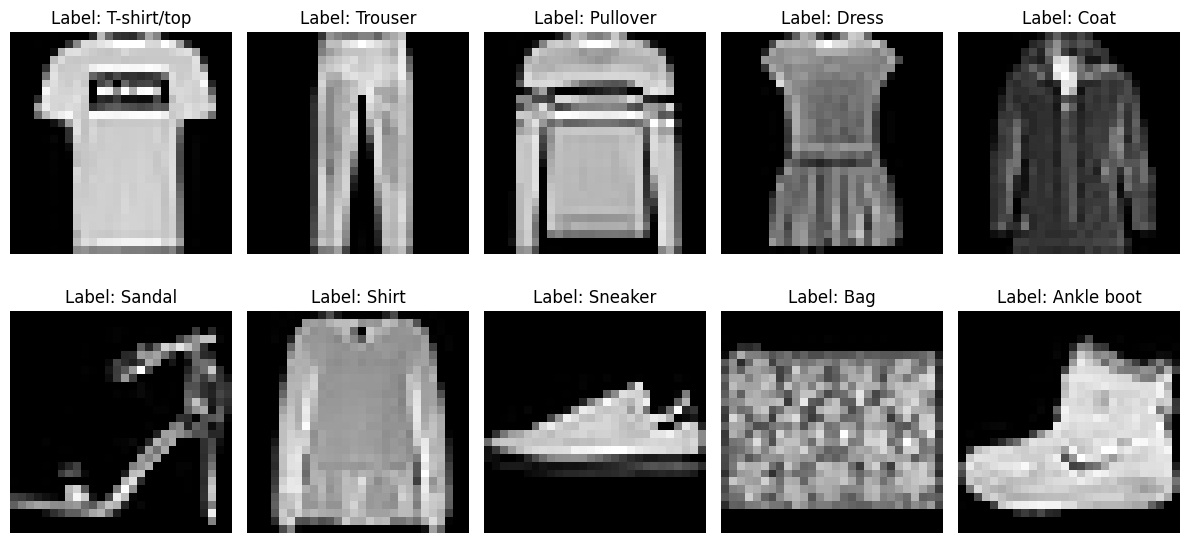

In [4]:
# Create a figure to display the images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel() # Flatten the 2x5 grid into a 1D array

# Loop through each digit from 0 to 9
for i in range(10):
    # Find the first index of the current digit in the training labels
    idx = np.where(y_train == i)[0][0]
    
    # Get the corresponding image from the training data
    image = X_train[idx]
    
    # Display the image on the appropriate subplot
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {label_dict[i]}")
    axes[i].axis('off') # Hide the axes

plt.tight_layout()
plt.show()

##### Vorbereitung der Daten 

Die Daten müssen für die Eingabe in das FCNN vorbereitet werden. Dazu werden die 28x28 Pixel großen Bilder in Vektoren der Länge 784 (28*28) umgewandelt. Außerdem werden die Pixelwerte normalisiert, indem sie durch 255 geteilt werden, um Werte zwischen 0 und 1 zu erhalten.

Die Labels werden in eine One-Hot_Kodieriung umgewandelt. D.h. die Labels (Ziffern 0-9) werden in einen binären Vektor der Länge 10 umgewandelt, wobei die Position der Ziffer auf 1 gesetzt wird und alle anderen Positionen auf 0. Zum Beispiel wird die Ziffer '3' als [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] kodiert.

In [5]:
#--------------------------------------------------
# Flatten
#--------------------------------------------------
X_train = X_train.reshape(-1, 28 * 28)
X_test  = X_test.reshape(-1, 28 * 28)

#--------------------------------------------------
# Normieren
#--------------------------------------------------
X_train   = X_train / 255
X_test  = X_test  / 255

#--------------------------------------------------
# One-Hot-Kodierung
#--------------------------------------------------
y_train_oneHot = tf.keras.utils.to_categorical(y_train, 10)
y_test_oneHot = tf.keras.utils.to_categorical(y_test, 10)

##### Anzeigen der abgewandelten Datenstruktur

In [6]:
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train_oneHot.shape}")

print(f"One-Hot-Encoding: \n {y_train_oneHot[0:10,:]}")

print(f"Beispiel-Bild (Ausschnitt): \n {X_train[55][200:250]}")

Trainingsdaten: (60000, 784), Labels: (60000, 10)
One-Hot-Encoding: 
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
Beispiel-Bild (Ausschnitt): 
 [0.33333333 0.70588235 0.68627451 0.77647059 0.59607843 0.60392157
 0.62352941 0.64705882 0.7254902  0.63137255 0.59215686 0.63529412
 0.61568627 0.69803922 0.75686275 0.79607843 0.81960784 0.80784314
 0.76862745 0.92156863 0.25490196 0.         0.         0.
 0.         0.         0.         0.         0.56470588 0.72156863
 0.69803922 0.8        0.60392157 0.61568627 0.66666667 0.69411765
 0.74117647 0.62352941 0.6        0.64313725 0.63137255 0.70196078
 0.77254902 0.79607843 0.83921569 0.83529412 0.76078431 0.83529412
 0.4745098  0.        ]


In [7]:
#--------------------------------------------------# Define and KERAS / TensorFlow Sequential Model)
#--------------------------------------------------# define initila values initializers
init_kernel = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
init_bias   = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)

model_fcn = Sequential()
model_fcn.add(tf.keras.Input(shape=(28*28,)))
model_fcn.add(tf.keras.layers.Dense(64, activation="sigmoid", kernel_initializer = init_kernel, bias_initializer = init_bias))
model_fcn.add(tf.keras.layers.Dense(32, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))
model_fcn.add(tf.keras.layers.Dense(10, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))

model_fcn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#--------------------------------------------------
# define custom MSE loss function  
#--------------------------------------------------
def my_mse(y_true,y_pred):
    L = tf.reduce_mean(tf.square(tf.subtract(y_true,y_pred)))
    return L

In [9]:
#--------------------------------------------------
# Modell kompilieren
#------------------------------------------------

model_fcn.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.7), loss="MeanSquaredError", metrics=['accuracy'])

#--------------------------------------------------
# Modell trainieren
#--------------------------------------------------
history_fcn = model_fcn.fit(X_train, y_train_oneHot, batch_size=35, epochs=150, verbose=1, validation_split=0.1)

Epoch 1/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3535 - loss: 0.0851 - val_accuracy: 0.5263 - val_loss: 0.0671
Epoch 2/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6010 - loss: 0.0593 - val_accuracy: 0.6508 - val_loss: 0.0533
Epoch 3/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6725 - loss: 0.0505 - val_accuracy: 0.6953 - val_loss: 0.0470
Epoch 4/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7029 - loss: 0.0457 - val_accuracy: 0.7190 - val_loss: 0.0434
Epoch 5/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7195 - loss: 0.0427 - val_accuracy: 0.7332 - val_loss: 0.0411
Epoch 6/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7306 - loss: 0.0406 - val_accuracy: 0.7408 - val_loss: 0.0395
Epoch 7/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7397 - loss: 0.0390 - val_accuracy: 0.7492 - val_loss: 0.0381
Epoch 8/150
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7470 - loss: 0

------------------------------------------
Klassifikationsgenauigkeit (Trainingsende)
------------------------------------------
88.32036852836609  Prozent


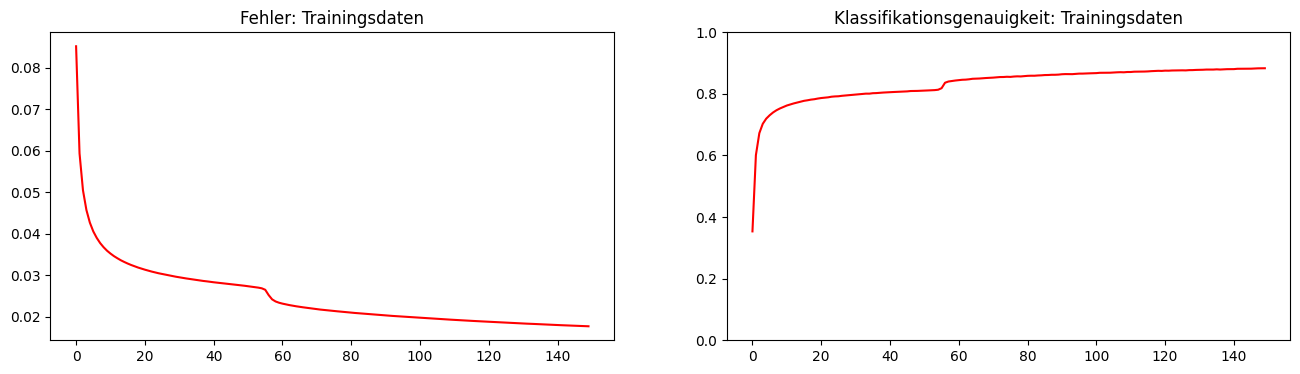

In [10]:
fig, ax = plt.subplots(1,2, squeeze=False,figsize=(16, 4))

ax[0,0].plot(history_fcn.history['loss'],"r")
ax[0,1].plot(history_fcn.history['accuracy'],"r")
ax[0,1].set_ylim([0,1])


ax[0,0].set_title("Fehler: Trainingsdaten")
t=ax[0,1].set_title("Klassifikationsgenauigkeit: Trainingsdaten")

print("------------------------------------------")
print("Klassifikationsgenauigkeit (Trainingsende)")
print("------------------------------------------")
print(np.max(history_fcn.history['accuracy'])*100 , " Prozent")

In [11]:
# klassifikation auf Testdaten durchführen
test_loss, test_accuracy = model_fcn.evaluate(X_test, y_test_oneHot, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8494 - loss: 0.0225


In [12]:
print("------------------------------------------")
print("Klassifikationsgenauigkeit Testdate )")
print("------------------------------------------")
print(test_accuracy*100 , " Prozent")


------------------------------------------
Klassifikationsgenauigkeit Testdate )
------------------------------------------
84.9399983882904  Prozent


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


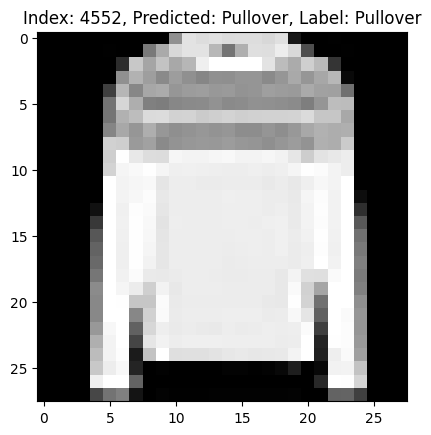

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


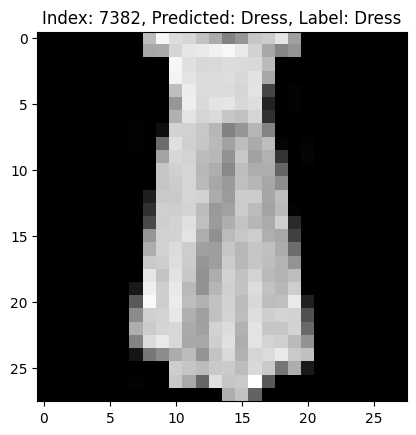

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


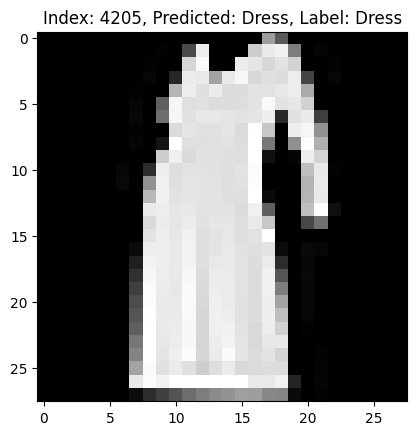

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


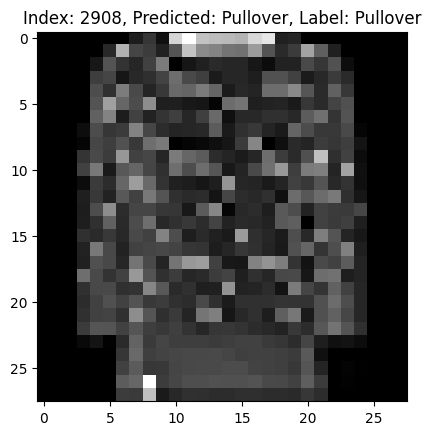

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


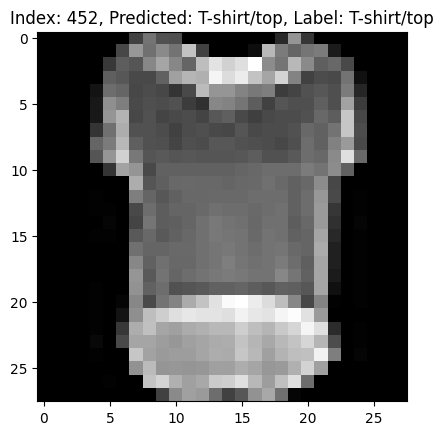

In [13]:
# 10 random numbers from test set
random_indices = np.random.randint(0, X_test.shape[0], size=5)

for index in random_indices:
    example_image = X_test[index,:].reshape(1,28*28)
    example_label = y_test[index]
    example_prediction = model_fcn.predict(example_image)
    predicted_label = np.argmax(example_prediction)

    #print(f'index {index}')
    #print(f'predicted {predicted_label}')
    #print(f'actual {example_label}')

    plt.figure()
    plt.imshow(example_image.reshape(28,28), cmap='gray')
    plt.title(f'Index: {index}, Predicted: {label_dict[predicted_label]}, Label: {label_dict[example_label]}')
    plt.show()


In [14]:
# identify and print misclassified examples
predictions = model_fcn.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
misclassified_indices = np.where(predicted_labels != y_test)[0]
print(f'Anzahl falsch klassifizierter Objekte: {misclassified_indices.shape}')
print(predictions.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
Anzahl falsch klassifizierter Objekte: (1506,)
(10000, 10)


Falsche Klassifizierungen: 1506


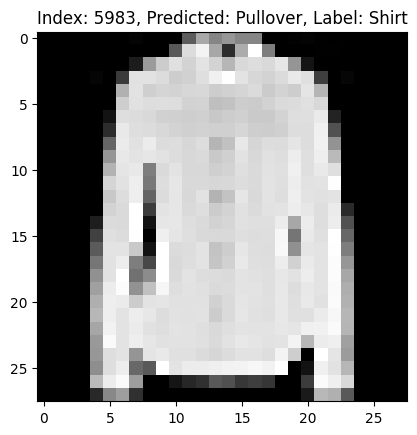

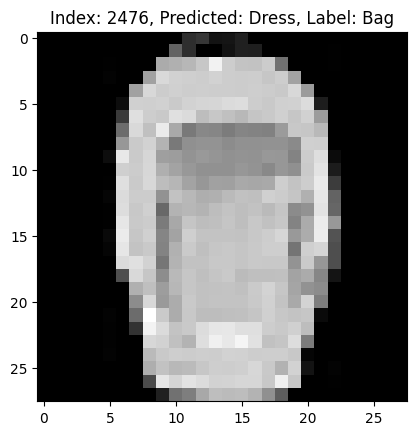

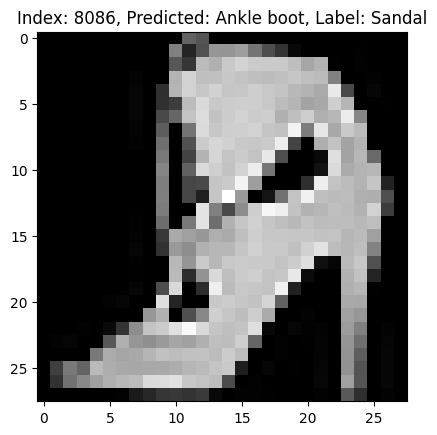

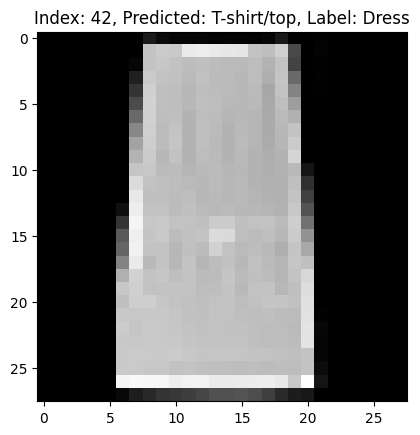

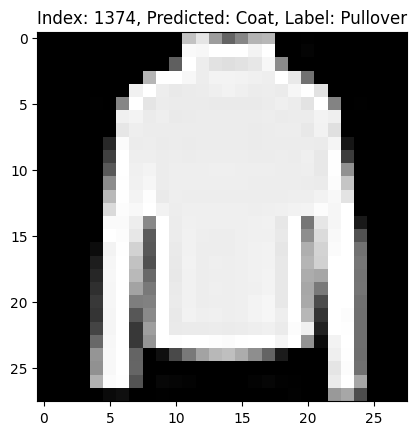

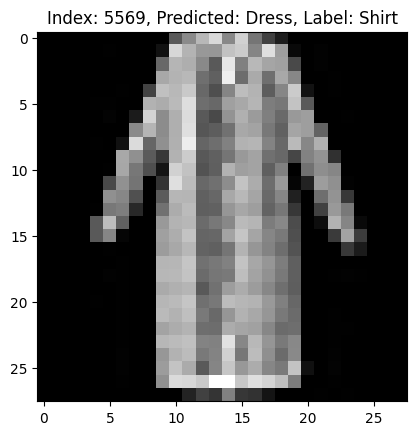

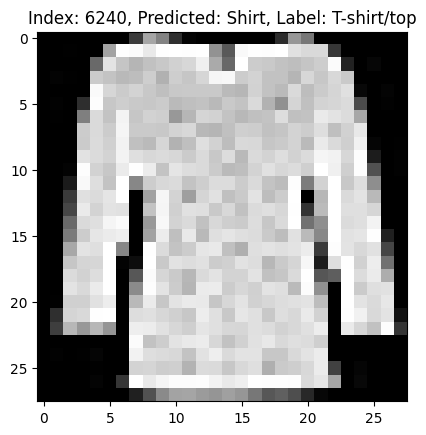

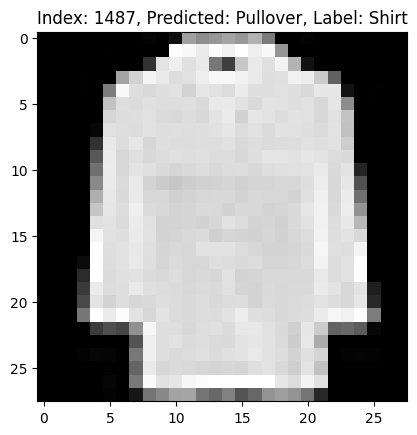

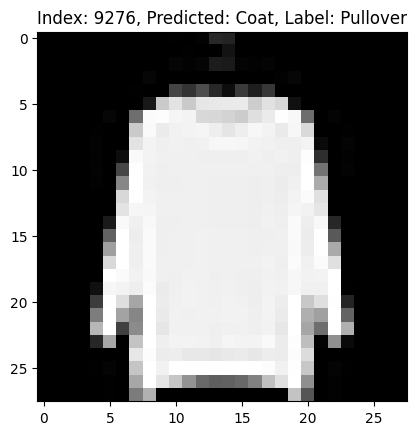

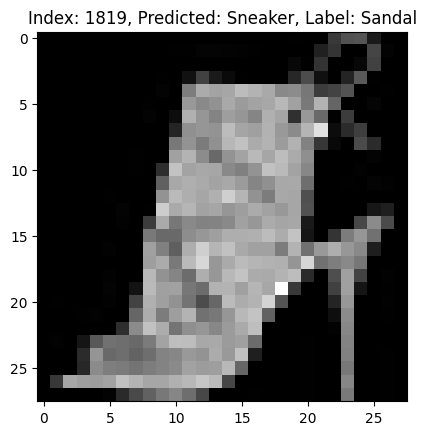

In [15]:
print(f'Falsche Klassifizierungen: {misclassified_indices.shape[0]}')


# print number of misclassified examples
indices = np.random.randint(0, misclassified_indices.shape[0], size=10)
indices = misclassified_indices[indices]

for index in indices:
    example_image = X_test[index,:].reshape(28,28)
    predicted_label = predicted_labels[index]
    actual_label = y_test[index]

    plt.figure()
    plt.imshow(example_image, cmap='gray')
    plt.title(f'Index: {index}, Predicted: {label_dict[predicted_label]}, Label: {label_dict[actual_label]}')
    plt.show()

In [16]:
print(predicted_labels.shape)
print(y_test.shape)

(10000,)
(10000,)


In [17]:
cMat_test = tf.math.confusion_matrix(
    predicted_labels,
    y_test,
    num_classes=None,
    weights=None,
    dtype=tf.dtypes.int32,
    name=None
)


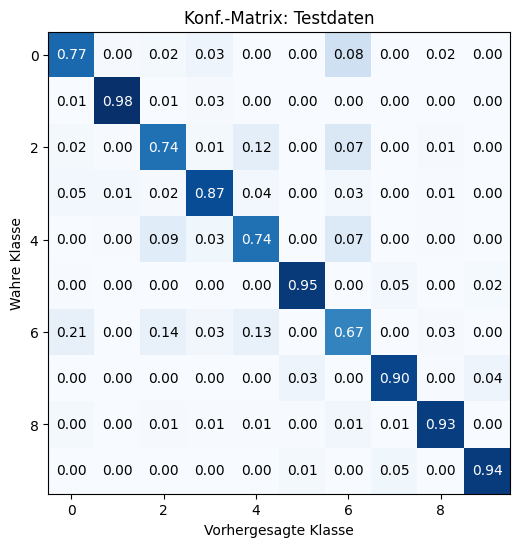

In [18]:
fig, ax_ = plt.subplots(1,1, squeeze=False,figsize=(6, 6))
#----------------------------------
# Konfusionsmatrix ausgeben
#----------------------------------
modules.matrixPlotting.plotConfusionMatrix(cMat_test,  True, ax_[0,0],txt="Konf.-Matrix: Testdaten") 